In [ ]:
#---------------------------------------------importing all necessary libraries---------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import(accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve)

## Importing Necessary Libraries

The required Python libraries are imported for data manipulation, visualization, preprocessing, model training, and evaluation.

- **Pandas & NumPy:** Data handling and numerical computations.
- **Matplotlib & Seaborn:** Data visualization.
- **StandardScaler:** Feature scaling.
- **train_test_split:** Splitting the dataset into training and testing sets.
- **Logistic Regression, Decision Tree, Random Forest, KNN, SVM:** Machine learning classification algorithms.
- **Accuracy, Precision, Recall, F1-score, ROC-AUC, ROC Curve:** Performance evaluation metrics used to compare the classification models.

In [ ]:
#----------------------------------------------------loading dataset-------------------------------------------------------------------
df = pd.read_csv('/content/drive/MyDrive/OSTAD/Datasets/diabetes.csv')

## Loading the Dataset

The dataset is loaded using the `pd.read_csv()` function from the Pandas library. The data is stored in a DataFrame named `df`, which will be used for data exploration, preprocessing, visualization, and machine learning model development.

In [ ]:
#-----------------------------------------------------Data Exploration-----------------------------------------------------------------

#showing first few rows of the dataset
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Data Exploration

The `head()` function is used to display the first five rows of the dataset. It provides a quick overview of the dataset's structure, column names, and sample records, helping verify that the data has been loaded correctly.

In [ ]:
#--------------------------------------------------showing the shape of the dataset----------------------------------------------------

df.shape

(768, 9)

## Checking the Dataset Shape

The `shape` attribute is used to determine the dimensions of the dataset. It returns the number of rows (samples) and columns (features), providing a quick overview of the dataset size.

In [ ]:
#-----------------------------------------------------checking for missing values------------------------------------------------------

df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## Checking for Missing Values

The `isnull().sum()` function is used to identify missing values in each column of the dataset. This helps determine whether data cleaning or imputation is required before further analysis and model training.

In [ ]:
#------------------------------------------------------showing basic statistics--------------------------------------------------------

df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Generating Summary Statistics

The `describe()` function provides descriptive statistics for all numerical features in the dataset. It displays measures such as count, mean, standard deviation, minimum, maximum, and quartiles, helping to understand the distribution and characteristics of the data before further analysis.

In [ ]:
#-----------------------------------------------------checking dataset information-----------------------------------------------------

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## Checking Dataset Information

The `info()` function provides a summary of the dataset, including the number of entries, column names, data types, non-null values, and memory usage. This helps verify the dataset's structure and identify any potential data quality issues before preprocessing.

In [ ]:
#---------------------------------------------------Zero value handling---------------------------------------------------------------
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_with_zeros:
    df[col] = df[col].replace(0, df[col].median())

## Handling Invalid Zero Values

Medically invalid zero values in selected features are replaced with the respective column median. This improves data quality and helps enhance the performance of the machine learning models.

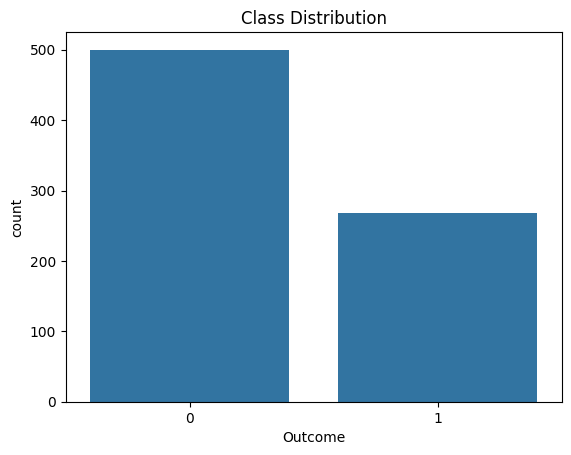

In [ ]:
#----------------------------------------------------EDA Data Visualization------------------------------------------------------------

#class distribution
sns.countplot(x='Outcome', data=df)
plt.title("Class Distribution")
plt.show()

## Class Distribution

A count plot is used to visualize the distribution of the target variable (`Outcome`). It shows the number of diabetic and non-diabetic cases, helping identify whether the dataset is balanced or imbalanced.

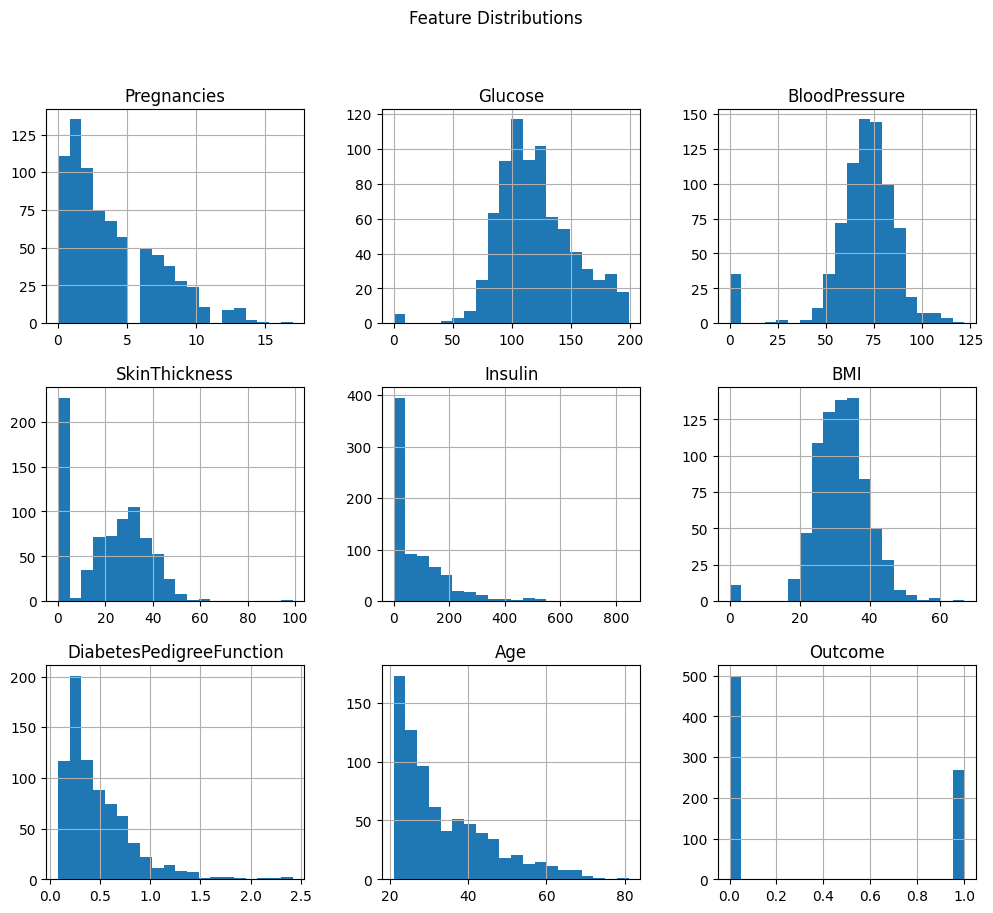

In [ ]:
#Feature Distribution

df.hist(figsize=(12,10), bins=20)
plt.suptitle('Feature Distributions')
plt.show()

```markdown id="jv3m7d"
## Feature Distribution

Histograms are used to visualize the distribution of each numerical feature. They help understand the data distribution, detect skewness, identify outliers, and observe the range of values for each feature.
```


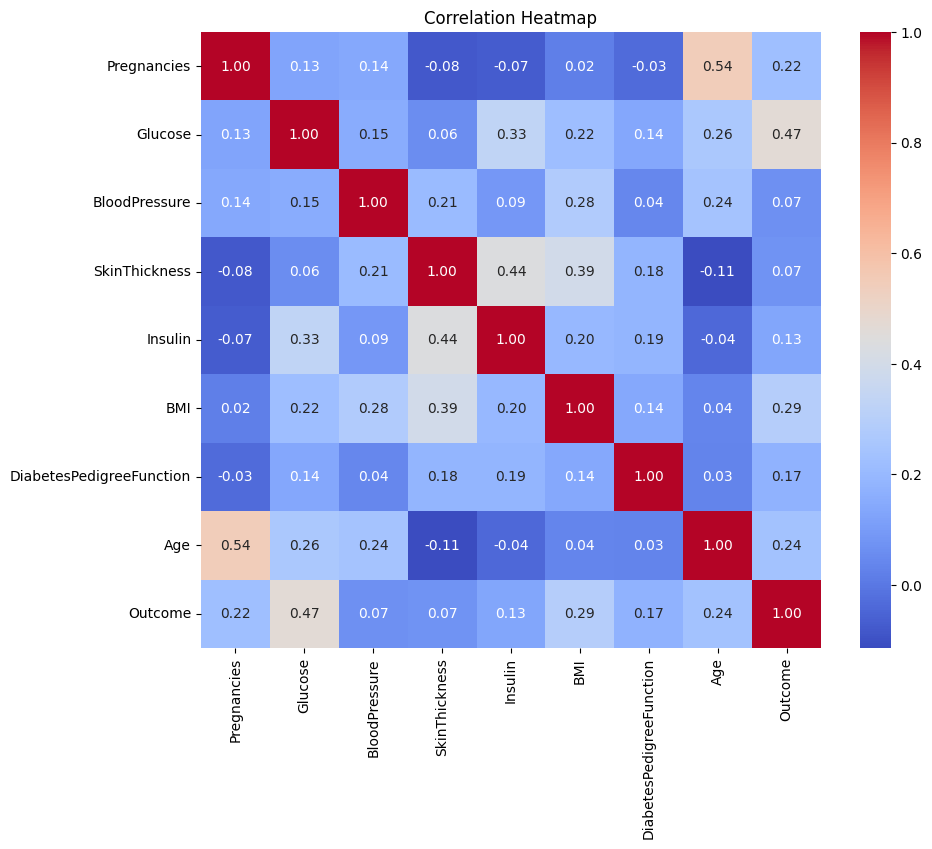

In [ ]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Correlation Heatmap

A correlation heatmap is used to visualize the relationships between numerical features. It helps identify positively or negatively correlated variables and understand how each feature is related to the target variable.

In [ ]:
#-------------------------------------------------Separating features (X) and target (y)-----------------------------------------------
X=df.drop('Outcome', axis=1)
y=df['Outcome']

## Separating Features and Target Variable

The dataset is divided into features (`X`) and the target variable (`y`). The `Outcome` column is used as the target, while all remaining columns are used as input features for model training.

In [ ]:
#-------------------------------------------------Split into test and train set--------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Splitting the Dataset

The dataset is split into training and testing sets using an 80:20 ratio. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.

In [ ]:
#-----------------------------------------------------------Feature Scaling------------------------------------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


## Feature Scaling

Feature scaling is performed using `StandardScaler` to standardize the input features. The scaler is fitted on the training data and then applied to both the training and testing sets to ensure consistent feature scaling.

In [ ]:
#------------------------------------------------------Model Creation and Training--------------------------------------------------
lr_model = LogisticRegression()
lr_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

SVC(probability=True)

## Model Training

Five machine learning classification models are trained using the training dataset: Logistic Regression, Random Forest, Decision Tree, K-Nearest Neighbors (KNN), and Support Vector Machine (SVM). These models are later evaluated and compared to determine the best-performing classifier.


In [ ]:
#-----------------------------------------------------------Model Evaluation-----------------------------------------------------------

models = {
    'Logistic Regression':lr_model,
    'Random Forest':rf_model,
    'Decision Tree':dt_model,
    'KNN':knn_model,
    'SVM':svm_model
}

results={}

for name, model in models.items():
  pred = model.predict(X_test)
  prob = model.predict_proba(X_test)[:,1]

  results[name] = {
      'Accuracy': accuracy_score(y_test, pred),
      'Precision': precision_score(y_test, pred),
      'Recall': recall_score(y_test, pred),
      'F1-score': f1_score(y_test, pred),
      'ROC-AUC': roc_auc_score(y_test, prob)
  }


results_df = pd.DataFrame(results).T
print(results_df)

                     Accuracy  Precision    Recall  F1-score   ROC-AUC
Logistic Regression  0.753247   0.649123  0.672727  0.660714  0.814692
Random Forest        0.720779   0.607143  0.618182  0.612613  0.812489
Decision Tree        0.746753   0.625000  0.727273  0.672269  0.742424
KNN                  0.694805   0.583333  0.509091  0.543689  0.764096
SVM                  0.733766   0.645833  0.563636  0.601942  0.804959


## Model Evaluation

The trained models are evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC. These metrics provide a comprehensive assessment of each model's performance, and the results are summarized in a DataFrame for comparison.


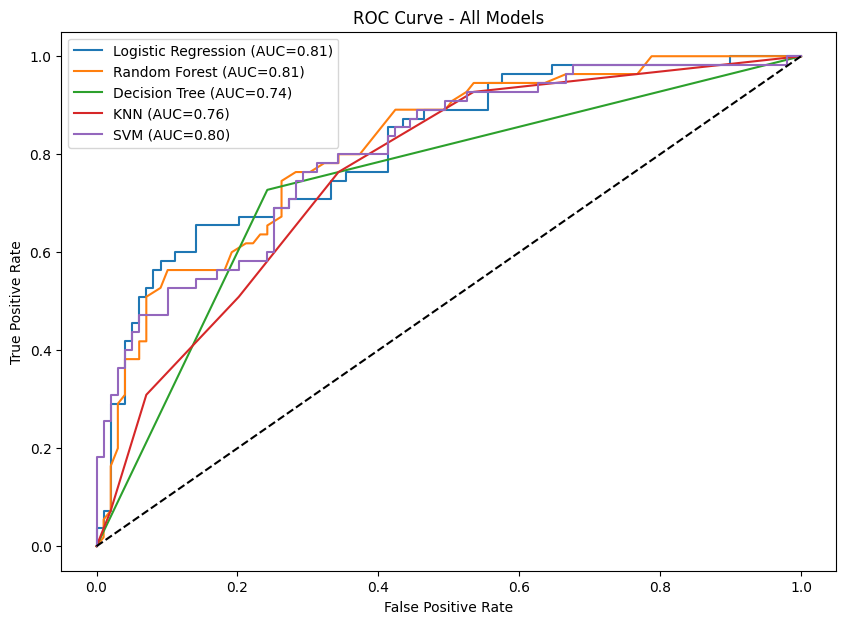

In [ ]:
#-----------------------------------------------------------ROC Curve-----------------------------------------------------------

plt.figure(figsize=(10,7))

for name, model in models.items():
    prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All Models')
plt.legend()
plt.show()

## ROC Curve

The ROC Curve is used to compare the performance of all classification models. It illustrates the trade-off between the True Positive Rate (Recall) and the False Positive Rate, while the ROC-AUC score measures each model's ability to distinguish between the two classes.

In [ ]:
#-----------------------------------------------------------Best Model Selection-----------------------------------------------------------

best_name = results_df['F1-score'].idxmax()
best_model = models[best_name]

print(f"Best Model: {best_name}")
print(results_df.loc[best_name])

import joblib
joblib.dump(best_model, "diabetes_model.pkl")
print("Model Saved Successfully")

Best Model: Decision Tree
Accuracy     0.746753
Precision    0.625000
Recall       0.727273
F1-score     0.672269
ROC-AUC      0.742424
Name: Decision Tree, dtype: float64
Model Saved Successfully


## Best Model Selection

The model with the highest F1-score is selected as the best-performing model. It is then saved as a `.pkl` file using `joblib` for future use without retraining.